In [10]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count
from environments import CorridorEnvTerminalReward
from utils import annotated_heatmap, analytical_policy_evaluation, epsilon_greedy_policy
from plotting import plot_policy

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

MAX_EPISODE_DURATION = 100

In [2]:
class PolicyNetwork(nn.Module):
    def __init__(self, n_states, n_hidden, n_actions):
        super(PolicyNetwork, self).__init__()
        # Using an Embedding or One-Hot input for discrete states
        self.affine = nn.Linear(n_states, n_hidden)
        self.action_head = nn.Linear(n_hidden, n_actions)

    def forward(self, x):
        # x is state index; convert to one-hot for the network
        x = F.one_hot(torch.tensor(x), num_classes=env.nS).float()
        x = F.relu(self.affine(x))
        action_prob = F.softmax(self.action_head(x), dim=-1)
        return action_prob

def train_reinforce(env, episodes=500, gamma=0.99, lr=1e-2):
    n_hidden = 32
    policy = PolicyNetwork(env.nS, n_hidden, env.nA)
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    
    for ep in range(episodes):
        state = env.reset()
        log_probs = []
        rewards = []
        done = False
        
        # 1. Collect Episode
        while not done:
            probs = policy(state)
            m = torch.distributions.Categorical(probs)
            action = m.sample()
            log_probs.append(m.log_prob(action))
            
            # Sample from the environment model (CorridorEnvTerminalReward logic)
            transitions = env.step(state, action.item())
            # transitions = [(p1, s_, r, d), (p2, s, r, d)]
            idx = np.random.choice(len(transitions), p=[t[0] for t in transitions])
            _, next_state, reward, done = transitions[idx]
            
            rewards.append(reward)
            state = next_state
            
            if len(rewards) > MAX_EPISODE_DURATION: # Safety break for infinite loops
                break

        # 2. Calculate Returns (G_t)
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        
        returns = torch.tensor(returns)
        # Whitening returns (normalization) helps stabilize training
        returns = (returns - returns.mean()) / (returns.std() + 1e-9)

        # 3. Update Policy
        policy_loss = []
        for log_prob, Gt in zip(log_probs, returns):
            policy_loss.append(-log_prob * Gt)
        
        optimizer.zero_grad()
        policy_loss = torch.stack(policy_loss).sum()
        policy_loss.backward()
        optimizer.step()

        if ep % 50 == 0:
            print(f"Episode {ep} | Total Reward: {sum(rewards)}")

    return policy


In [3]:
env = CorridorEnvTerminalReward(n_states=10, is_slippery=True)
trained_policy = train_reinforce(env)

Episode 0 | Total Reward: 10.0
Episode 50 | Total Reward: 10.0
Episode 100 | Total Reward: 10.0
Episode 150 | Total Reward: 10.0
Episode 200 | Total Reward: 10.0
Episode 250 | Total Reward: 10.0
Episode 300 | Total Reward: 10.0
Episode 350 | Total Reward: 10.0
Episode 400 | Total Reward: 10.0
Episode 450 | Total Reward: 10.0


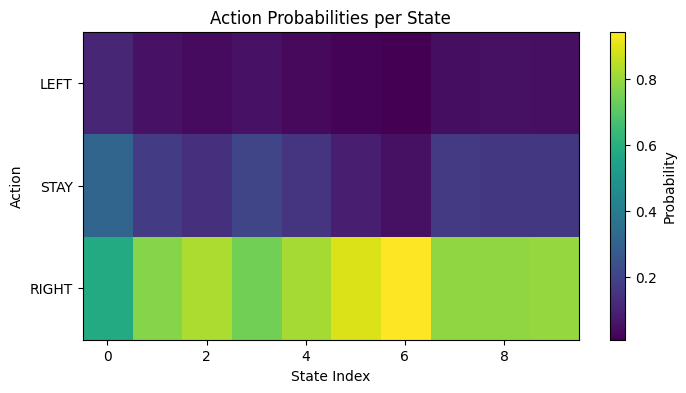

In [4]:
# Extract probabilities for each state
policy_probs = []
for s in range(env.nS):
    with torch.no_grad():
        probs = trained_policy(s).numpy()
    policy_probs.append(probs)
policy_probs = np.array(policy_probs)

# --- Plot 1: Heatmap ---
plt.figure(figsize=(8, 4))
plt.imshow(policy_probs.T, aspect='auto', cmap='viridis')
plt.colorbar(label='Probability')
plt.xlabel('State Index')
plt.ylabel('Action')
plt.yticks([0, 1, 2], ['LEFT', 'STAY', 'RIGHT'])
plt.title('Action Probabilities per State')
plt.show()

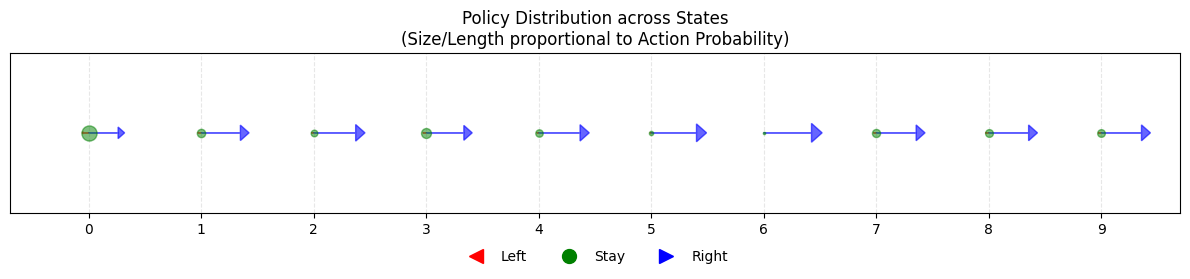

In [11]:
plot_policy(policy_probs)

## Evaluate the trained policy

In [12]:
done = False
state = np.random.randint(0, env.nS)
rewards = []

while not done:
            probs = trained_policy(state)
            pi = torch.distributions.Categorical(probs)
            action = pi.sample()
            
            # Sample from the environment model (CorridorEnvTerminalReward logic)
            transitions = env.step(state, action.item())
            # transitions = [(p1, s_, r, d), (p2, s, r, d)]
            idx = np.random.choice(len(transitions), p=[t[0] for t in transitions])
            _, next_state, reward, done = transitions[idx]
            
            rewards.append(reward)
            state = next_state